# Barra-Style Macro Factor Model — A-Share Stocks

This notebook builds a macro factor model to compare stock exposure and ensure they can perfectly hedge each other.

**Pipeline:**
1. Load & align macro factors (Shibor, LPR, CPI, PPI, M1/M2, SF, GDP)
2. Build a monthly factor matrix — stationary-transformed so regressions are valid
3. Estimate factor exposures two ways:
   - **OLS rolling regression** — direct, interpretable betas per factor
   - **PCA → regression** — orthogonal latent factors, removes multicollinearity
4. Compare two stocks via:
   - Side-by-side factor loading bar charts
   - Cosine similarity heatmap across a universe of stocks

In [3]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
import statsmodels.api as sm
from scipy import stats
import sys
from pathlib import Path

root = Path('.').resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# ── paths ────────────────────────────────────────────────────────────────────
ROOT       = Path('.')          # adjust if notebook is not in project root
MACRO_DB   = ROOT / 'data' / 'macroeconomics.sqlite'
PRICES_DB  = ROOT / 'data' / 'prices.sqlite'

print('Macro DB exists: ', MACRO_DB.exists())
print('Prices DB exists:', PRICES_DB.exists())

Macro DB exists:  True
Prices DB exists: True


In [4]:
# ── style ─────────────────────────────────────────────────────────────────────
BG        = '#0f1117'
PANEL     = '#161b22'
GRID      = '#21262d'
COL_A     = '#58a6ff'   # blue  – stock A
COL_B     = '#f78166'   # coral – stock B
TEXT      = '#e6edf3'
SUBTEXT   = '#8b949e'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   SUBTEXT,
    'xtick.color':       SUBTEXT,
    'ytick.color':       SUBTEXT,
    'grid.color':        GRID,
    'text.color':        TEXT,
    'font.family':       'monospace',
})

## 1  Load Macro Factors

In [5]:
def open_db(path: Path) -> sqlite3.Connection:
    conn = sqlite3.connect(path)
    conn.execute('PRAGMA journal_mode=WAL')
    return conn

macro_conn  = open_db(MACRO_DB)
prices_conn = open_db(PRICES_DB)

# helper: list tables in a db
def list_tables(conn):
    return [r[0] for r in conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")]

print('macro tables: ', list_tables(macro_conn))
print('prices tables:', list_tables(prices_conn))

macro tables:  ['_fetch_log', 'cn_cpi', 'cn_gdp', 'cn_m', 'cn_ppi', 'hibor', 'libor', 'sf_month', 'shibor', 'shibor_lpr', 'shibor_quote']
prices tables: ['adj_factor', 'csv_manifest', 'daily_prices', 'latest_daily_basic', 'sqlite_stat1', 'stock_basic', 'stock_company', 'stock_namechange', 'tushare_adj_date_fetch_status', 'tushare_adj_fetch_status', 'tushare_enrichment_summary', 'tushare_fetch_report']


In [6]:
# ── 1a  Shibor — use overnight rate as short-rate level ───────────────────────
shibor_raw = pd.read_sql(
    "SELECT * FROM shibor ORDER BY date",
    macro_conn, parse_dates=['date']
)

# on: float     SHIBOR overnight
# 1w: float     SHIBOR 1-week
# 2w: float     SHIBOR 2-week
# 1m: float     SHIBOR 1-month
# 3m: float     SHIBOR 3-month
# 6m: float     SHIBOR 6-month
# 9m: float     SHIBOR 9-month
# 1y: float     SHIBOR 1-year

# resample to month-end, take last observation
shibor_m = shibor_raw.set_index('date').resample('ME').last()

cols_to_keep = ['on', '3m', '1y']  # keep overnight, 3-month, and 1-year rates for short, medium, and long-term
shibor_m = shibor_m[cols_to_keep]

print('shibor:', shibor_m.shape)
shibor_m.tail(3)

shibor: (98, 3)


,on,3m,1y
date,,,
2026-04-30,1.327,1.4160,1.4720
2026-05-31,1.324,1.4075,1.4655
2026-06-30,1.384,1.4020,1.4600


In [7]:
# ── 1b  LPR ──────────────────────────────────────────────────────────────────
lpr_cols = pd.read_sql('PRAGMA table_info(shibor_lpr)', macro_conn)['name'].tolist()
print('shibor_lpr columns:', lpr_cols)

# typically columns: date, 1y (and maybe 5y post-2019)
lpr_raw = pd.read_sql('SELECT * FROM shibor_lpr ORDER BY date', macro_conn, parse_dates=['date'])
lpr_raw.columns = [c.replace('y','y_lpr') if c != 'date' else c for c in lpr_raw.columns]
lpr_m = lpr_raw.set_index('date').resample('ME').last()
print('lpr:', lpr_m.shape)
lpr_m.tail(3)

# 1y_lpr: float     Loan Prime Rate 1-year
# 5y_lpr: float     Loan Prime Rate 5-year (may be missing pre-2019)

shibor_lpr columns: ['date', '1y', '5y']
lpr: (123, 2)


,1y_lpr,5y_lpr
date,,
2026-01-31,3.0,3.5
2026-02-28,3.0,3.5
2026-03-31,3.0,3.5


In [8]:
# ── 1c  CPI — use nt_val (national YoY %) ────────────────────────────────────
cpi_cols = pd.read_sql('PRAGMA table_info(cn_cpi)', macro_conn)['name'].tolist()
print('cn_cpi columns:', cpi_cols)

cpi_raw = pd.read_sql('SELECT * FROM cn_cpi ORDER BY month', macro_conn)
cpi_raw['date'] = pd.to_datetime(cpi_raw['month'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
cpi_m = cpi_raw.set_index('date').drop(columns=['month'])
# keep only the headline national YoY series if available
# nt_val: float     National: current month value
# nt_yoy: float     National: YoY change (%)
# nt_mom: float     National: MoM change (%)
# nt_accu: float    National: YTD cumulative value
# town_val: float   Urban: current month value
# town_yoy: float   Urban: YoY change (%)
# town_mom: float   Urban: MoM change (%)
# town_accu: float  Urban: YTD cumulative value
# cnt_val: float    Rural: current month value
# cnt_yoy: float    Rural: YoY change (%)
# cnt_mom: float    Rural: MoM change (%)
# cnt_accu: float   Rural: YTD cumulative value

cols_to_keep = ['nt_yoy', 'nt_mom']
cpi_m = cpi_m[cols_to_keep]

print('cpi:', cpi_m.shape)
cpi_m.tail(3)

cn_cpi columns: ['month', 'nt_val', 'nt_yoy', 'nt_mom', 'nt_accu', 'town_val', 'town_yoy', 'town_mom', 'town_accu', 'cnt_val', 'cnt_yoy', 'cnt_mom', 'cnt_accu']
cpi: (124, 2)


,nt_yoy,nt_mom
date,,
2026-02-28,1.3,1.0
2026-03-31,1.0,-0.7
2026-04-30,1.2,0.3


In [9]:
# ── 1d  PPI ───────────────────────────────────────────────────────────────────
ppi_cols = pd.read_sql('PRAGMA table_info(cn_ppi)', macro_conn)['name'].tolist()
print('cn_ppi columns:', ppi_cols)

ppi_raw = pd.read_sql('SELECT * FROM cn_ppi ORDER BY month', macro_conn)
ppi_raw['date'] = pd.to_datetime(ppi_raw['month'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
ppi_m = ppi_raw.set_index('date').drop(columns=['month'])

#  --- YoY (当月同比) ---
# ppi_yoy: float        PPI: All industrial goods, YoY (%)
# ppi_mp_yoy: float     PPI: Means of production, YoY (%)
# ppi_mp_qm_yoy: float  PPI: Means of production - Mining, YoY (%)
# ppi_mp_rm_yoy: float  PPI: Means of production - Raw materials, YoY (%)
# ppi_mp_p_yoy: float   PPI: Means of production - Processing, YoY (%)
# ppi_cg_yoy: float     PPI: Consumer goods, YoY (%)
# ppi_cg_f_yoy: float   PPI: Consumer goods - Food, YoY (%)
# ppi_cg_c_yoy: float   PPI: Consumer goods - Clothing, YoY (%)
# ppi_cg_adu_yoy: float PPI: Consumer goods - General daily use, YoY (%)
# ppi_cg_dcg_yoy: float PPI: Consumer goods - Durable goods, YoY (%)

#  --- MoM (环比) ---
# ppi_mom: float        PPI: All industrial goods, MoM (%)
# ppi_mp_mom: float     PPI: Means of production, MoM (%)
# ppi_mp_qm_mom: float  PPI: Means of production - Mining, MoM (%)
# ppi_mp_rm_mom: float  PPI: Means of production - Raw materials, MoM (%)
# ppi_mp_p_mom: float   PPI: Means of production - Processing, MoM (%)
# ppi_cg_mom: float     PPI: Consumer goods, MoM (%)
# ppi_cg_f_mom: float   PPI: Consumer goods - Food, MoM (%)
# ppi_cg_c_mom: float   PPI: Consumer goods - Clothing, MoM (%)
# ppi_cg_adu_mom: float PPI: Consumer goods - General daily use, MoM (%)
# ppi_cg_dcg_mom: float PPI: Consumer goods - Durable goods, MoM (%)

#  --- YTD Cumulative YoY (累计同比) ---
# ppi_accu: float        PPI: All industrial goods, YTD YoY (%)
# ppi_mp_accu: float     PPI: Means of production, YTD YoY (%)
# ppi_mp_qm_accu: float  PPI: Means of production - Mining, YTD YoY (%)
# ppi_mp_rm_accu: float  PPI: Means of production - Raw materials, YTD YoY (%)
# ppi_mp_p_accu: float   PPI: Means of production - Processing, YTD YoY (%)
# ppi_cg_accu: float     PPI: Consumer goods, YTD YoY (%)
# ppi_cg_f_accu: float   PPI: Consumer goods - Food, YTD YoY (%)
# ppi_cg_c_accu: float   PPI: Consumer goods - Clothing, YTD YoY (%)
# ppi_cg_adu_accu: float PPI: Consumer goods - General daily use, YTD YoY (%)
# ppi_cg_dcg_accu: float PPI: Consumer goods - Durable goods, YTD YoY (%)

cols_to_keep = ['ppi_yoy', 'ppi_mp_yoy', 'ppi_mom', 'ppi_cg_yoy']
ppi_m = ppi_m[cols_to_keep]

# In addition, we are adding ppi_mp_yoy - ppi_cg_yoy as a potential leading indicator of industrial vs consumer price trends
ppi_m['ppi_mp_cg_diff_yoy'] = ppi_m['ppi_mp_yoy'] - ppi_m['ppi_cg_yoy']

print('ppi:', ppi_m.shape)
ppi_m.tail(3)

cn_ppi columns: ['month', 'ppi_yoy', 'ppi_mp_yoy', 'ppi_mp_qm_yoy', 'ppi_mp_rm_yoy', 'ppi_mp_p_yoy', 'ppi_cg_yoy', 'ppi_cg_f_yoy', 'ppi_cg_c_yoy', 'ppi_cg_adu_yoy', 'ppi_cg_dcg_yoy', 'ppi_mom', 'ppi_mp_mom', 'ppi_mp_qm_mom', 'ppi_mp_rm_mom', 'ppi_mp_p_mom', 'ppi_cg_mom', 'ppi_cg_f_mom', 'ppi_cg_c_mom', 'ppi_cg_adu_mom', 'ppi_cg_dcg_mom', 'ppi_accu', 'ppi_mp_accu', 'ppi_mp_qm_accu', 'ppi_mp_rm_accu', 'ppi_mp_p_accu', 'ppi_cg_accu', 'ppi_cg_f_accu', 'ppi_cg_c_accu', 'ppi_cg_adu_accu', 'ppi_cg_dcg_accu']
ppi: (124, 5)


,ppi_yoy,ppi_mp_yoy,ppi_mom,ppi_cg_yoy,ppi_mp_cg_diff_yoy
date,,,,,
2026-02-28,-0.9,-0.7,0.4,-1.6,0.9
2026-03-31,0.5,1.0,1.0,-1.3,2.3
2026-04-30,2.8,3.8,1.7,-1.0,4.8


In [10]:
# ── 1e  Money Supply — M1 YoY and M2 YoY ─────────────────────────────────────
m_cols = pd.read_sql('PRAGMA table_info(cn_m)', macro_conn)['name'].tolist()
print('cn_m columns:', m_cols)

m_raw = pd.read_sql('SELECT * FROM cn_m ORDER BY month', macro_conn)
m_raw['date'] = pd.to_datetime(m_raw['month'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
m_m = m_raw.set_index('date').drop(columns=['month'])

# pick M1 yoy and M2 yoy — column names vary by Tushare version
m1_col = next((c for c in m_m.columns if 'm1' in c.lower() and 'yoy' in c.lower()), None)
m2_col = next((c for c in m_m.columns if 'm2' in c.lower() and 'yoy' in c.lower()), None)
# fallback: take M1/M2 level and compute MoM pct change
if m1_col is None:
    m1_col = next((c for c in m_m.columns if 'm1' in c.lower()), None)
if m2_col is None:
    m2_col = next((c for c in m_m.columns if 'm2' in c.lower()), None)

# month: str       Month (YYYYMM)
# m0: float        M0 money supply (100M CNY) — currency in circulation
# m0_yoy: float    M0 YoY (%)
# m0_mom: float    M0 MoM (%)
# m1: float        M1 money supply (100M CNY) — M0 + demand deposits
# m1_yoy: float    M1 YoY (%)
# m1_mom: float    M1 MoM (%)
# m2: float        M2 money supply (100M CNY) — M1 + time/savings deposits
# m2_yoy: float    M2 YoY (%)
# m2_mom: float    M2 MoM (%)

cols_to_keep = ['m1_yoy', 'm2_yoy', 'm1_mom', 'm2_mom']
m_m = m_m[cols_to_keep]

# In addition to those, we are adding m1_yoy - m2_yoy and m1_mom - m2_mom as potential leading 
# indicators of credit conditions (M1 is more closely tied to economic activity, while M2 includes more stable time deposits)

m_m['m1_m2_yoy_diff'] = m_m['m1_yoy'] - m_m['m2_yoy']
m_m['m1_m2_mom_diff'] = m_m['m1_mom'] - m_m['m2_mom']

print('money supply:', m_m.shape)
m_m.tail(3)

cn_m columns: ['month', 'm0', 'm0_yoy', 'm0_mom', 'm1', 'm1_yoy', 'm1_mom', 'm2', 'm2_yoy', 'm2_mom']
money supply: (124, 6)


,m1_yoy,m2_yoy,m1_mom,m2_mom,m1_m2_yoy_diff,m1_m2_mom_diff
date,,,,,,
2026-02-28,5.9,9.0,-1.73,0.59,-3.1,-2.32
2026-03-31,5.1,8.5,2.93,1.33,-3.4,1.60
2026-04-30,5.0,8.6,-3.97,-0.23,-3.6,-3.74


In [11]:
# ── 1f  Social Financing ──────────────────────────────────────────────────────
sf_cols = pd.read_sql('PRAGMA table_info(sf_month)', macro_conn)['name'].tolist()
print('sf_month columns:', sf_cols)

sf_raw = pd.read_sql('SELECT * FROM sf_month ORDER BY month', macro_conn)
sf_raw['date'] = pd.to_datetime(sf_raw['month'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
sf_m = sf_raw.set_index('date').drop(columns=['month'])

# TSF = Total Social Financing, a broad measure of credit and liquidity in the economy 
# includes bonds, shadow banking, equity financing etc. 
# inc_month: float     TSF: monthly flow (100M CNY)
# inc_cumval: float    TSF: YTD cumulative flow (100M CNY)
# stk_endval: float    TSF: outstanding stock at month-end (1T CNY)

print('social financing:', sf_m.shape)
sf_m.tail(3)

sf_month columns: ['month', 'inc_month', 'inc_cumval', 'stk_endval']
social financing: (292, 3)


,inc_month,inc_cumval,stk_endval
date,,,
2026-02-28,23837.0,96022.0,451.40
2026-03-31,52240.0,148262.0,456.46
2026-04-30,6245.0,154507.0,456.89


In [12]:
# ── 1g  GDP — quarterly, forward-fill to monthly ─────────────────────────────
gdp_cols = pd.read_sql('PRAGMA table_info(cn_gdp)', macro_conn)['name'].tolist()
print('cn_gdp columns:', gdp_cols)

gdp_raw = pd.read_sql('SELECT * FROM cn_gdp ORDER BY quarter', macro_conn)

def quarter_to_date(q_str):
    """Convert '2023Q4' → last day of that quarter."""
    year, q = q_str.split('Q')
    month = int(q) * 3
    return pd.Timestamp(year=int(year), month=month, day=1) + pd.offsets.MonthEnd(0)

gdp_raw['date'] = gdp_raw['quarter'].apply(quarter_to_date)
gdp_m_q = gdp_raw.set_index('date').drop(columns=['quarter'])

# pick headline GDP growth column
gdp_col = ['gdp_yoy', 'si_yoy', 'ti_yoy', 'si_yoy - ti_yoy']

# quarter: str       Quarter (e.g. 2024Q1)
# gdp: float         GDP: YTD cumulative (100M CNY)
# gdp_yoy: float     GDP: current quarter YoY growth (%)
# pi: float          Primary industry (agriculture): YTD cumulative (100M CNY)
# pi_yoy: float      Primary industry: YoY growth (%) agriculture - skipped because it is only 7% of gdp and tends to be stable
# si: float          Secondary industry (manufacturing/construction): YTD cumulative (100M CNY)
# si_yoy: float      Secondary industry: YoY growth (%) manufacturing + construction
# ti: float          Tertiary industry (services): YTD cumulative (100M CNY)
# ti_yoy: float      Tertiary industry: YoY growth (%) service 

gdp_m_q['si_yoy - ti_yoy'] = gdp_m_q['si_yoy'] - gdp_m_q['ti_yoy']
gdp_q = gdp_m_q[gdp_col]

# resample to monthly index then forward-fill (GDP only changes quarterly)
idx_m = pd.date_range(gdp_q.index.min(), gdp_q.index.max(), freq='ME')
gdp_m = gdp_q.reindex(idx_m).ffill()
print('gdp (monthly fwd-filled):', gdp_m.shape)
gdp_m.tail(6)

cn_gdp columns: ['quarter', 'gdp', 'gdp_yoy', 'pi', 'pi_yoy', 'si', 'si_yoy', 'ti', 'ti_yoy']
gdp (monthly fwd-filled): (118, 4)


,gdp_yoy,si_yoy,ti_yoy,si_yoy - ti_yoy
2025-07-31,5.3,5.3,5.5,-0.2
2025-08-31,5.3,5.3,5.5,-0.2
2025-09-30,5.2,4.9,5.4,-0.5
2025-10-31,5.2,4.9,5.4,-0.5
2025-11-30,5.2,4.9,5.4,-0.5
2025-12-31,5.0,4.5,5.4,-0.9


## 2  Build Factor Matrix

All series are aligned to a common monthly index. Stationarity transforms applied:
- **Rate levels** (Shibor, LPR): month-on-month change (Δ rate)
- **YoY series** (CPI, PPI, M1/M2, GDP): already stationary as growth rates — use as-is
- **Social Financing**: YoY computed above

In [13]:
# SHIBOR
# levels already in %; derive curve factors
shibor_m['shibor_slope'] = (shibor_m['1y'] - shibor_m['on'])
shibor_m['shibor_curve'] = (2 * shibor_m['3m'] - shibor_m['on'] - shibor_m['1y'])

# MoM changes to capture rate momentum
shibor_m['shibor_on_chg']    = shibor_m['on'].diff()
shibor_m['shibor_3m_chg']    = shibor_m['3m'].diff()
shibor_m['shibor_1y_chg']    = shibor_m['1y'].diff()
shibor_m['shibor_slope_chg'] = shibor_m['shibor_slope'].diff()

shibor_m['shibor_on'] = shibor_m['on']
shibor_m['shibor_3m'] = shibor_m['3m']
shibor_m['shibor_1y'] = shibor_m['1y']

cols_shibor = [
    'shibor_on', 'shibor_3m', 'shibor_1y',      # levels
    'shibor_slope', 'shibor_curve',             # curve shape
    'shibor_on_chg', 'shibor_3m_chg',           # momentum
    'shibor_1y_chg', 'shibor_slope_chg',
]

# LPR
lpr_m['lpr_spread'] = lpr_m['5y_lpr'] - lpr_m['1y_lpr']   # term spread; 5y drives mortgage/capex

# MoM changes — LPR cuts/hikes are the policy signal
lpr_m['lpr_1y_chg']     = lpr_m['1y_lpr'].diff()
lpr_m['lpr_5y_chg']     = lpr_m['5y_lpr'].diff()
lpr_m['lpr_spread_chg'] = lpr_m['lpr_spread'].diff()

cols_lpr = [
    '1y_lpr', '5y_lpr',                        # levels
    'lpr_spread',                               # term spread
    'lpr_1y_chg', 'lpr_5y_chg',               # policy signals
    'lpr_spread_chg',
]

# CPI
cpi_m['cpi_yoy_chg'] = cpi_m['nt_yoy'].diff()   # acceleration/deceleration
cpi_m['cpi_mom_chg'] = cpi_m['nt_mom'].diff()   # second derivative of prices

cpi_m['cpi_yoy'] = cpi_m['nt_yoy']
cpi_m['cpi_mom'] = cpi_m['nt_mom']

cols_cpi = [
    'cpi_yoy',                                   # level: inflation regime
    'cpi_mom',                                   # momentum
    'cpi_yoy_chg',                             # acceleration
    'cpi_mom_chg'                             # turning point signal
]

# PPI
ppi_m['ppi_scissors'] = ppi_m['ppi_mp_yoy'] - ppi_m['ppi_cg_yoy']  # upstream vs downstream margin pressure
ppi_m['ppi_yoy_chg']      = ppi_m['ppi_yoy'].diff()                 # acceleration
ppi_m['ppi_mp_yoy_chg']   = ppi_m['ppi_mp_yoy'].diff()
ppi_m['ppi_scissors_chg'] = ppi_m['ppi_scissors'].diff()            # margin pressure momentum

cols_ppi = [
    'ppi_yoy',                                  # headline
    'ppi_mp_yoy',                              # upstream
    'ppi_cg_yoy',                              # downstream
    'ppi_scissors',                            # margin pressure spread
    'ppi_mom',                                 # turning point signal
    'ppi_yoy_chg',                             # acceleration
    'ppi_mp_yoy_chg',                          # upstream acceleration
    'ppi_scissors_chg',
]

# MONEY SUPPLY
m_m['m1_m2_spread']     = m_m['m1_yoy'] - m_m['m2_yoy']  # liquidity preference signal
m_m['m1_yoy_chg']       = m_m['m1_yoy'].diff()                # acceleration in narrow money
m_m['m2_yoy_chg']       = m_m['m2_yoy'].diff()
m_m['m1_m2_spread_chg'] = m_m['m1_m2_spread'].diff()

cols_money = [
    'm1_yoy', 'm2_yoy',                        # monetary regime
    'm1_m2_spread',                            # liquidity preference
    'm1_yoy_chg', 'm2_yoy_chg',               # acceleration
    'm1_m2_spread_chg',
]

# SOCIAL FINANCING (TSF)
# inc_month in 100M CNY — normalize to YoY and impulse
sf_m['sf_inc_yoy']    = sf_m['inc_month'].pct_change(12)
sf_m['tsf_rolling12'] = sf_m['inc_month'].rolling(12).sum()
sf_m['tsf_impulse']   = sf_m['tsf_rolling12'].diff(12)

# normalize impulse to % of rolling12 to make it scale-invariant over time
sf_m['tsf_impulse_pct'] = sf_m['tsf_impulse'] / sf_m['tsf_rolling12'].shift(12) * 100

cols_sf = [
    'sf_inc_yoy',                              # credit growth rate
    'tsf_impulse_pct',                         # normalized credit acceleration
]

# ============================================================
# GDP
gdp_m['si_ti_spread'] = gdp_m['si_yoy'] - gdp_m['ti_yoy']  # industry mix: cyclicals vs services

# acceleration
gdp_m['gdp_yoy_chg'] = gdp_m['gdp_yoy'].diff(3)   # QoQ change (diff by 3 months since ffilled)

cols_gdp = ['gdp_yoy', 'si_yoy', 'ti_yoy', 'si_ti_spread', 'gdp_yoy_chg']

# ============================================================
# MERGE ALL INTO ONE MACRO FEATURE FRAME
# ============================================================
factor_df = (
    shibor_m[cols_shibor]
    .join(lpr_m[cols_lpr],    how='outer')
    .join(cpi_m[cols_cpi],    how='outer')
    .join(ppi_m[cols_ppi],    how='outer')
    .join(m_m[cols_money], how='outer')
    .join(sf_m[cols_sf],      how='outer')
    .join(gdp_m[cols_gdp],    how='outer')
)

# cross-series derived features 

# tracks pass-through from producer to consumer prices; widening spread can signal margin pressure and potential inflation acceleration
factor_df['cpi_ppi_spread']   = factor_df['cpi_yoy'] - factor_df['ppi_yoy'] 

# LPR vs SHIBOR spread — measures transmission gap between policy rate and interbank market; widening spread can signal monetary tightening or financial stress
factor_df['lpr_shibor_spread'] = factor_df['1y_lpr'] - factor_df['shibor_1y']

# forward-fill any remaining gaps (e.g. GDP, LPR which change infrequently)
factor_df = factor_df.ffill()

FACTOR_NAMES = list(factor_df.columns)
print('Raw factor matrix shape:', factor_df.shape)
print('Factors:', FACTOR_NAMES)
print(factor_df.isna().sum())
factor_df.tail(6)

Raw factor matrix shape: (294, 42)
Factors: ['shibor_on', 'shibor_3m', 'shibor_1y', 'shibor_slope', 'shibor_curve', 'shibor_on_chg', 'shibor_3m_chg', 'shibor_1y_chg', 'shibor_slope_chg', '1y_lpr', '5y_lpr', 'lpr_spread', 'lpr_1y_chg', 'lpr_5y_chg', 'lpr_spread_chg', 'cpi_yoy', 'cpi_mom', 'cpi_yoy_chg', 'cpi_mom_chg', 'ppi_yoy', 'ppi_mp_yoy', 'ppi_cg_yoy', 'ppi_scissors', 'ppi_mom', 'ppi_yoy_chg', 'ppi_mp_yoy_chg', 'ppi_scissors_chg', 'm1_yoy', 'm2_yoy', 'm1_m2_spread', 'm1_yoy_chg', 'm2_yoy_chg', 'm1_m2_spread_chg', 'sf_inc_yoy', 'tsf_impulse_pct', 'gdp_yoy', 'si_yoy', 'ti_yoy', 'si_ti_spread', 'gdp_yoy_chg', 'cpi_ppi_spread', 'lpr_shibor_spread']
shibor_on            196
shibor_3m            196
shibor_1y            196
shibor_slope         196
shibor_curve         196
shibor_on_chg        197
shibor_3m_chg        197
shibor_1y_chg        197
shibor_slope_chg     197
1y_lpr               168
5y_lpr               211
lpr_spread           211
lpr_1y_chg           169
lpr_5y_chg         

,shibor_on,shibor_3m,shibor_1y,shibor_slope,shibor_curve,shibor_on_chg,shibor_3m_chg,shibor_1y_chg,shibor_slope_chg,1y_lpr,...,m1_m2_spread_chg,sf_inc_yoy,tsf_impulse_pct,gdp_yoy,si_yoy,ti_yoy,si_ti_spread,gdp_yoy_chg,cpi_ppi_spread,lpr_shibor_spread
date,,,,,,,,,,,,,,,,,,,,,
2026-01-31,1.328,1.5890,1.6280,0.3000,0.2220,0.001,-0.0110,-0.0220,-0.0230,3.0,...,0.6,0.023233,8.913216,5.0,4.5,5.4,-0.9,-0.2,1.6,1.372
2026-02-28,1.318,1.5679,1.6040,0.2860,0.2138,-0.010,-0.0211,-0.0240,-0.0140,3.0,...,1.0,0.067440,6.970504,5.0,4.5,5.4,-0.9,-0.2,2.2,1.396
2026-03-31,1.277,1.5070,1.5380,0.2610,0.1990,-0.041,-0.0609,-0.0660,-0.0250,3.0,...,-0.3,-0.113991,1.748855,5.0,4.5,5.4,-0.9,-0.2,0.5,1.462
2026-04-30,1.327,1.4160,1.4720,0.1450,0.0330,0.050,-0.0910,-0.0660,-0.1160,3.0,...,-0.2,-0.461592,-3.221201,5.0,4.5,5.4,-0.9,-0.2,-1.6,1.462
2026-05-31,1.324,1.4075,1.4655,0.1415,0.0255,-0.003,-0.0085,-0.0065,-0.0035,3.0,...,-0.2,-0.461592,-3.221201,5.0,4.5,5.4,-0.9,-0.2,-1.6,1.462
2026-06-30,1.384,1.4020,1.4600,0.0760,-0.0400,0.060,-0.0055,-0.0055,-0.0655,3.0,...,-0.2,-0.461592,-3.221201,5.0,4.5,5.4,-0.9,-0.2,-1.6,1.462


first date to start: 2019-09-30 00:00:00


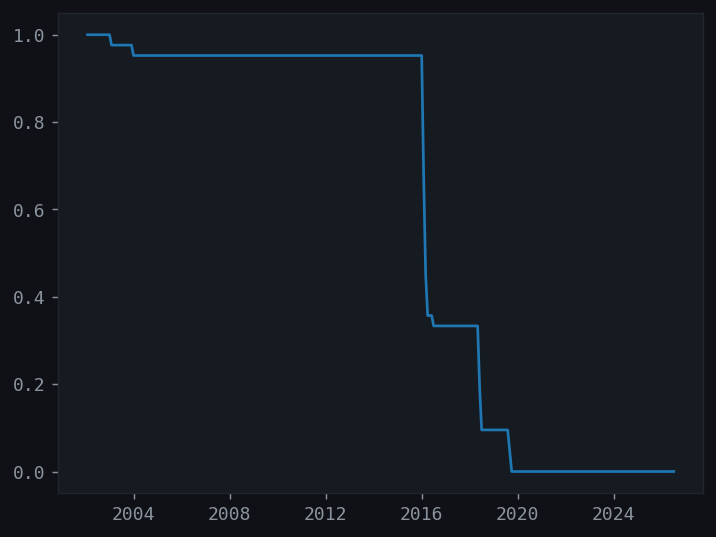

In [14]:
# Checking number of missing values by dates 
# most features are missing prior to 2015 when data collection started, but we have a good coverage from 2015 onwards
# we will be running the analysis from 2016 onwards to ensure robustness of results and avoid lookahead bias from backfilled data
plt.plot(factor_df.isna().sum(axis = 1) / factor_df.shape[1])
start_date = factor_df.loc[factor_df.isna().sum(axis = 1) / factor_df.shape[1] == 0.0].index.min()
print(f"first date to start: {start_date}")

In [15]:
factor_df = factor_df.loc['2019-09-30':]

In [16]:
# check for outliers
z_scores = factor_df.apply(stats.zscore, nan_policy='omit').abs()
outlier_counts = (z_scores > 3).sum().sort_values(ascending=False)
print(outlier_counts[outlier_counts > 0])
factor_df.describe().T.assign(
    range=lambda x: x['max'] - x['min'],
    cv=lambda x: x['std'] / x['mean'].abs()
).sort_values('cv', ascending=False)

lpr_1y_chg           4
lpr_5y_chg           4
si_ti_spread         3
m1_m2_spread_chg     3
si_yoy               3
gdp_yoy              3
shibor_1y_chg        3
gdp_yoy_chg          3
lpr_spread_chg       2
shibor_slope         2
m1_yoy_chg           2
lpr_shibor_spread    2
cpi_mom_chg          2
shibor_3m_chg        1
shibor_curve         1
shibor_on_chg        1
shibor_on            1
shibor_slope_chg     1
ppi_mom              1
cpi_yoy              1
sf_inc_yoy           1
m1_m2_spread         1
dtype: int64


,count,mean,std,min,25%,50%,75%,max,range,cv
m1_m2_spread_chg,82.0,0.009756,2.163194,-8.000000,-0.675000,-0.200000,0.500000,7.200000,15.200000,221.727421
m1_yoy_chg,82.0,0.017073,2.072739,-7.300000,-0.775000,-0.100000,0.875000,6.600000,13.900000,121.403301
shibor_slope_chg,82.0,-0.004915,0.461199,-2.200000,-0.122500,-0.012000,0.144750,1.305000,3.505000,93.842021
gdp_yoy_chg,82.0,-0.057317,4.493673,-12.900000,-0.300000,-0.100000,0.475000,16.600000,29.500000,78.400246
m2_yoy_chg,82.0,0.007317,0.503023,-1.300000,-0.300000,0.000000,0.400000,1.300000,2.600000,68.746488
cpi_yoy_chg,82.0,-0.014634,0.535210,-1.200000,-0.300000,0.000000,0.300000,1.500000,2.700000,36.572691
cpi_mom_chg,82.0,0.019512,0.652713,-2.000000,-0.300000,0.050000,0.475000,1.400000,3.400000,33.451544
lpr_spread_chg,82.0,-0.001220,0.039265,-0.250000,0.000000,0.000000,0.000000,0.100000,0.350000,32.196925
shibor_on_chg,82.0,-0.014488,0.427181,-1.190000,-0.122750,-0.014500,0.092250,2.189000,3.379000,29.485570
ppi_cg_yoy,82.0,-0.079268,1.149636,-1.700000,-1.175000,-0.200000,0.900000,2.200000,3.900000,14.503104


In [17]:
# since there aren't too many outliers, we will winsorize the few extreme values to prevent 
# them from dominating the PCA and regression results, especially given our relatively small sample size
factor_df = factor_df.clip(lower=factor_df.quantile(0.02), upper=factor_df.quantile(0.98), axis = 1)

In [18]:
# drop any remaining rows with ANY NaN — need complete factor rows for regression
factor_clean = factor_df.dropna()
print('Clean factor matrix:', factor_clean.shape)
print('Date range:', factor_clean.index[0].date(), '→', factor_clean.index[-1].date())

# standardise factors (z-score) — important for PCA and for comparing beta magnitudes
scaler = StandardScaler()
F = pd.DataFrame(
    scaler.fit_transform(factor_clean),
    index=factor_clean.index,
    columns=FACTOR_NAMES
)
F.tail(3)

Clean factor matrix: (82, 42)
Date range: 2019-09-30 → 2026-06-30


,shibor_on,shibor_3m,shibor_1y,shibor_slope,shibor_curve,shibor_on_chg,shibor_3m_chg,shibor_1y_chg,shibor_slope_chg,1y_lpr,...,m1_m2_spread_chg,sf_inc_yoy,tsf_impulse_pct,gdp_yoy,si_yoy,ti_yoy,si_ti_spread,gdp_yoy_chg,cpi_ppi_spread,lpr_shibor_spread
date,,,,,,,,,,,,,,,,,,,,,
2026-04-30,-1.251516,-1.605677,-1.697633,-1.026762,-0.291279,0.230346,-0.419387,-0.351893,-0.322029,-1.540953,...,-0.119509,-1.327148,-0.762973,-0.030154,-0.077055,-0.004691,-0.18464,-0.031947,-0.52698,1.02014
2026-05-31,-1.259596,-1.624403,-1.702481,-1.036048,-0.309932,0.076050,0.054949,0.083834,-0.025831,-1.540953,...,-0.119509,-1.327148,-0.762973,-0.030154,-0.077055,-0.004691,-0.18464,-0.031947,-0.52698,1.02014
2026-06-30,-1.097994,-1.629008,-1.702481,-1.209826,-0.472833,0.259459,0.072197,0.091157,-0.189069,-1.540953,...,-0.119509,-1.327148,-0.762973,-0.030154,-0.077055,-0.004691,-0.18464,-0.031947,-0.52698,1.02014


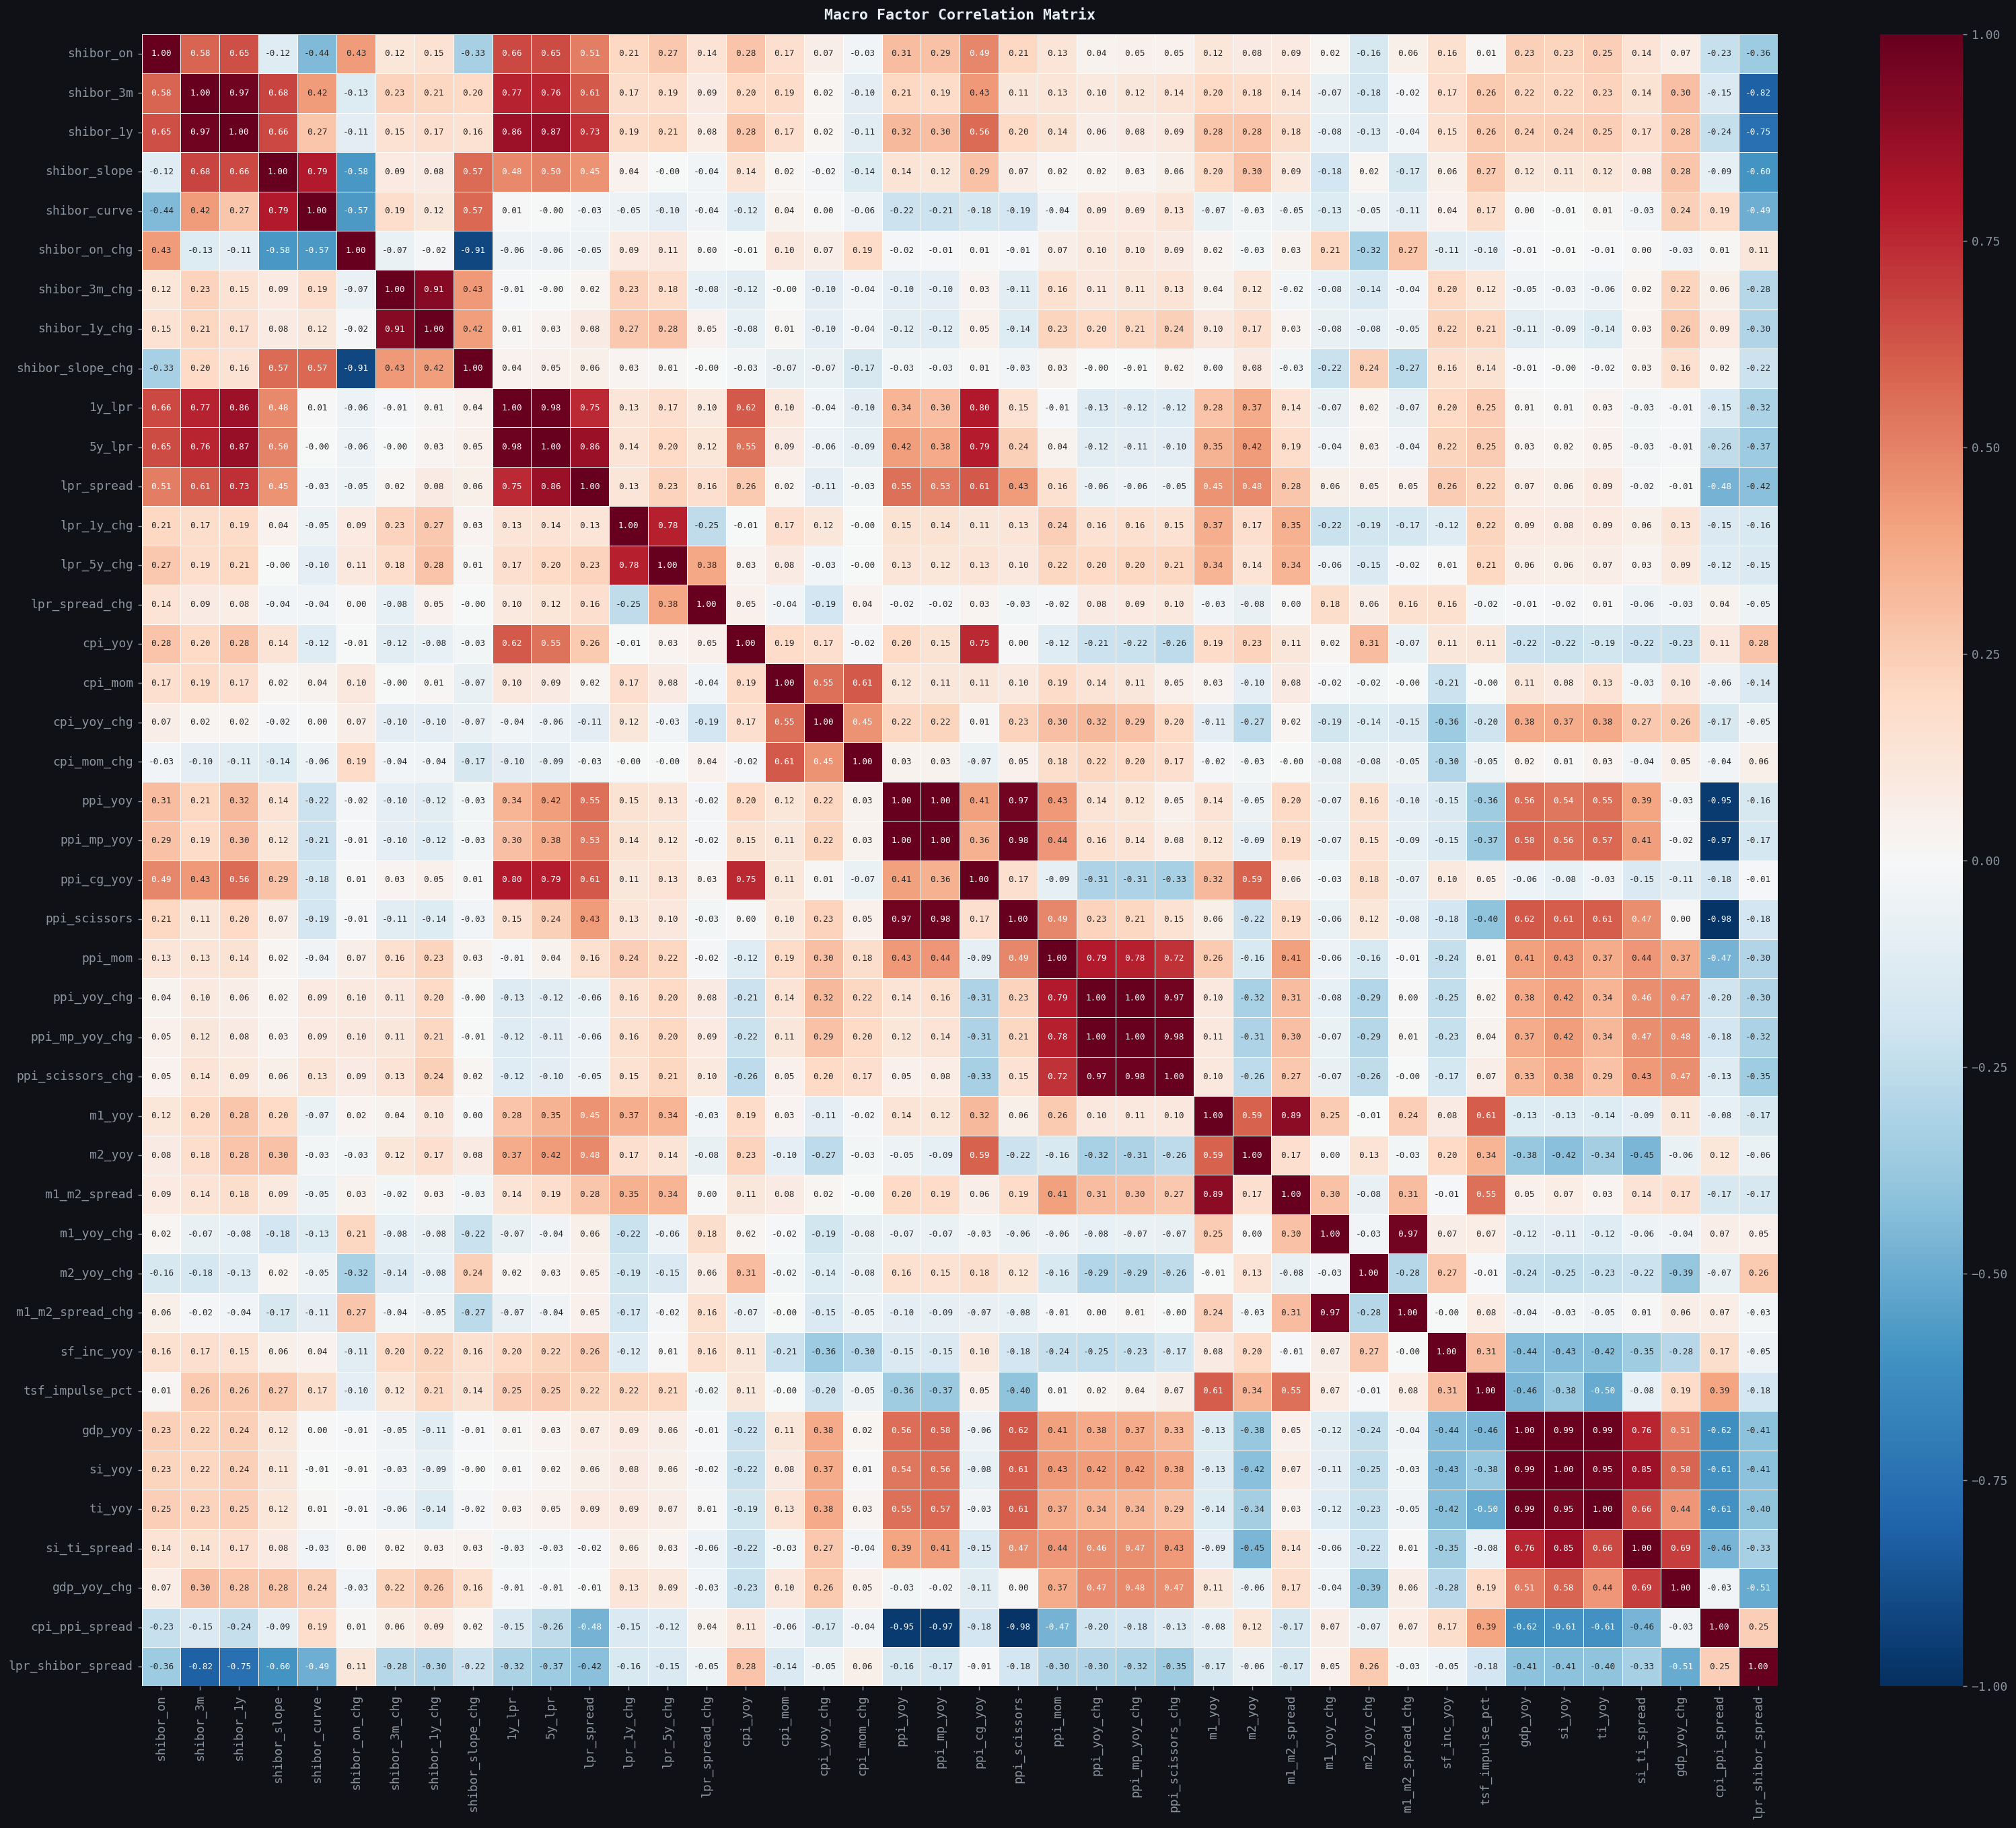

In [19]:
# factor correlation heatmap — check multicollinearity before OLS
n = len(F.columns)
fig, ax = plt.subplots(figsize=(n * 0.6, n * 0.5))
sns.heatmap(
    F.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    annot_kws={'size': 7}
)
ax.set_title('Macro Factor Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [20]:
print(factor_df['5y_lpr'].value_counts()) 
# note: lpr is slow moving and often has repeated values so it appears correlated with a bunch of other stuff
# since its only a little bit of collinearity and also its an important policy rate
# we will keep it in the downstream analysis but it's something to keep in mind when interpreting results

5y_lpr
4.650    21
3.500    14
4.300    10
4.200     8
3.600     7
3.950     5
4.600     4
4.800     3
4.450     3
3.850     3
4.819     2
4.750     2
Name: count, dtype: int64


## 3  Load Stock Returns

In [21]:
prices_tables = list_tables(prices_conn)
print('Available price tables:', prices_tables[:10], '...' if len(prices_tables) > 10 else '')

Available price tables: ['adj_factor', 'csv_manifest', 'daily_prices', 'latest_daily_basic', 'sqlite_stat1', 'stock_basic', 'stock_company', 'stock_namechange', 'tushare_adj_date_fetch_status', 'tushare_adj_fetch_status'] ...


In [22]:
# ── CONFIG: set your stock universe here ─────────────────────────────────────
# These are the stocks that will be used for the universe heatmap.
# The first two are also the pair used for side-by-side comparison.
# DO NOT READ the entire price table it's too big and WILL CRASH your kernel

from src.regression import load_monthly_returns

STOCK_UNIVERSE = [ # these are the most likely trading pairs from price analysis
    # '600519.SH',   # 贵州茅台
    # '000858.SZ',   # 五粮液
    # '601318.SH',   # 中国平安
    # '600036.SH',   # 招商银行
    # '000001.SZ',   # 平安银行
    # '600900.SH',   # 长江电力
    # '300750.SZ',   # 宁德时代
    # '002594.SZ',   # 比亚迪
    '600010.SH',  # 包钢股份 | 钢铁/稀土 | ~¥60B
    '600111.SH',  # 北方稀土 | 稀土材料 | ~¥90B
    '600030.SH',  # 中信证券 | 证券/投行 | ~¥350B
    '601211.SH',  # 国泰君安 | 证券/投行 | ~¥160B
    '300418.SZ',  # 昆仑万维 | 互联网/AI | ~¥55B
    '300624.SZ',  # 万兴科技 | 软件/创意 | ~¥10B
    '000762.SZ',  # 西藏矿业 | 锂矿/有色 | ~¥25B
    '600338.SH',  # 西藏珠峰 | 铜矿/有色 | ~¥15B
    '000977.SZ',  # 浪潮信息 | IT服务器  | ~¥45B
    '603019.SH',  # 中科曙光 | 高性能计算| ~¥35B
    '300118.SZ',  # 东方日升 | 光伏/新能源| ~¥15B
    '688599.SH',  # 天合光能 | 光伏组件  | ~¥60B
    '601788.SH',  # 光大证券 | 证券/投行 | ~¥70B
    '601881.SH',  # 中国银河 | 证券/投行 | ~¥120B
    '002407.SZ',  # 多氟多   | 氟化工/锂电| ~¥20B
    '002709.SZ',  # 天赐材料 | 锂电池材料| ~¥30B
]

# ── load prices ──────────────────────────────────────────────────────────────


# load all stocks
returns_dict = {}
for code in STOCK_UNIVERSE:
    try:
        returns_dict[code] = load_monthly_returns(code, prices_conn)
        print(f'  {code}: {len(returns_dict[code])} monthly observations')
    except Exception as e:
        print(f'  {code}: FAILED — {e}')

returns_df = pd.DataFrame(returns_dict)
print(f'\nReturns matrix: {returns_df.shape}')

  600010.SH: 120 monthly observations
  600111.SH: 120 monthly observations
  600030.SH: 120 monthly observations
  601211.SH: 120 monthly observations
  300418.SZ: 120 monthly observations
  300624.SZ: 101 monthly observations
  000762.SZ: 120 monthly observations
  600338.SH: 120 monthly observations
  000977.SZ: 120 monthly observations
  603019.SH: 120 monthly observations
  300118.SZ: 117 monthly observations
  688599.SH: 72 monthly observations
  601788.SH: 120 monthly observations
  601881.SH: 113 monthly observations
  002407.SZ: 120 monthly observations
  002709.SZ: 120 monthly observations

Returns matrix: (120, 16)


## 4  Align Returns & Factors

In [23]:
# align on common dates
common_idx = F.index.intersection(returns_df.index)
F_aligned = F.loc[common_idx]
R_aligned = returns_df.loc[common_idx]

print(f'Aligned observations: {len(common_idx)}')
print(f'Date range: {common_idx[0].date()} → {common_idx[-1].date()}')

# drop stocks with too many NaNs in the aligned window
valid_stocks = R_aligned.columns[R_aligned.isna().mean() < 0.2].tolist()
R_aligned = R_aligned[valid_stocks].dropna()
F_aligned = F_aligned.loc[R_aligned.index]

print(f'Valid stocks: {valid_stocks}')
print(f'Final aligned shape — Returns: {R_aligned.shape}, Factors: {F_aligned.shape}')

Aligned observations: 82
Date range: 2019-09-30 → 2026-06-30
Valid stocks: ['600010.SH', '600111.SH', '600030.SH', '601211.SH', '300418.SZ', '300624.SZ', '000762.SZ', '600338.SH', '000977.SZ', '603019.SH', '300118.SZ', '688599.SH', '601788.SH', '601881.SH', '002407.SZ', '002709.SZ']
Final aligned shape — Returns: (72, 16), Factors: (72, 42)


## 5  Method A — OLS Rolling Regression

For each stock, regress monthly excess returns on the standardised macro factors using a rolling window.
The final window's coefficients are the stock's **factor exposure vector**.

$$r_{i,t} = \alpha_i + \beta_{i,1} f_{1,t} + \beta_{i,2} f_{2,t} + \cdots + \beta_{i,k} f_{k,t} + \varepsilon_{i,t}$$

In [24]:
ROLLING_WINDOW = 36   # months — adjust to taste (min ~24 for stability)

from src.regression import ols_exposures, ols_rolling_exposures

# ── compute full-sample OLS exposures for all stocks ─────────────────────────
ols_exposure_matrix = pd.DataFrame({
    code: ols_exposures(R_aligned[code], F_aligned)[0]
    for code in valid_stocks
}).T
beta_se_matrix = pd.DataFrame({
    code: ols_exposures(R_aligned[code], F_aligned)[1]
    for code in valid_stocks
}).T

print('OLS exposure matrix (stocks × factors):')


OLS exposure matrix (stocks × factors):


## 6  Method B — PCA Factor Model

PCA extracts orthogonal (uncorrelated) latent components from the macro factor matrix.
This eliminates the multicollinearity problem visible in the correlation heatmap above.
We then regress stock returns on the principal components to get **PC loadings**,
and transform back to the original factor space for interpretability.

$$r_{i,t} = \alpha_i + \gamma_{i,1} PC_{1,t} + \cdots + \gamma_{i,k} PC_{k,t} + \varepsilon_{i,t}$$

Implied original-space exposure: $\beta^{PCA}_i = W \cdot \gamma_i$ where $W$ is the PCA loading matrix.

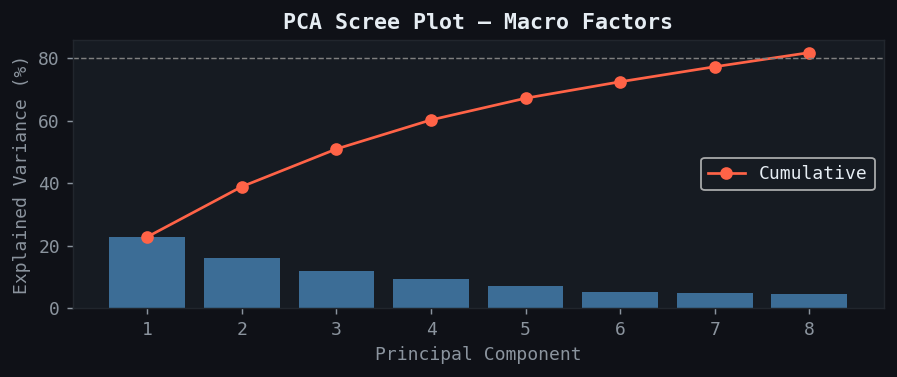

Explained variance per PC:
  PC1: 22.8%  (cumulative: 22.8%)
  PC2: 16.1%  (cumulative: 38.9%)
  PC3: 12.0%  (cumulative: 50.9%)
  PC4: 9.3%  (cumulative: 60.2%)
  PC5: 6.9%  (cumulative: 67.2%)
  PC6: 5.3%  (cumulative: 72.4%)
  PC7: 4.8%  (cumulative: 77.2%)
  PC8: 4.5%  (cumulative: 81.7%)


In [25]:
N_COMPONENTS = 8 # min(len(FACTOR_NAMES), len(F_aligned) // 5)  # conservative

pca = PCA(n_components=N_COMPONENTS)
PC_scores = pd.DataFrame(
    pca.fit_transform(F_aligned),
    index=F_aligned.index,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

# explained variance
evr = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, N_COMPONENTS + 1), evr * 100, color='steelblue', alpha=0.8)
ax.plot(range(1, N_COMPONENTS + 1), np.cumsum(evr) * 100,
        'o-', color='tomato', label='Cumulative')
ax.axhline(80, linestyle='--', color='grey', linewidth=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Scree Plot — Macro Factors', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Explained variance per PC:')
for i, v in enumerate(evr):
    print(f'  PC{i+1}: {v*100:.1f}%  (cumulative: {np.cumsum(evr)[i]*100:.1f}%)')

In [26]:
print(np.linalg.cond(PC_scores.T @ PC_scores)) # so much better - now the linear regression is legit 

5.043660959305447


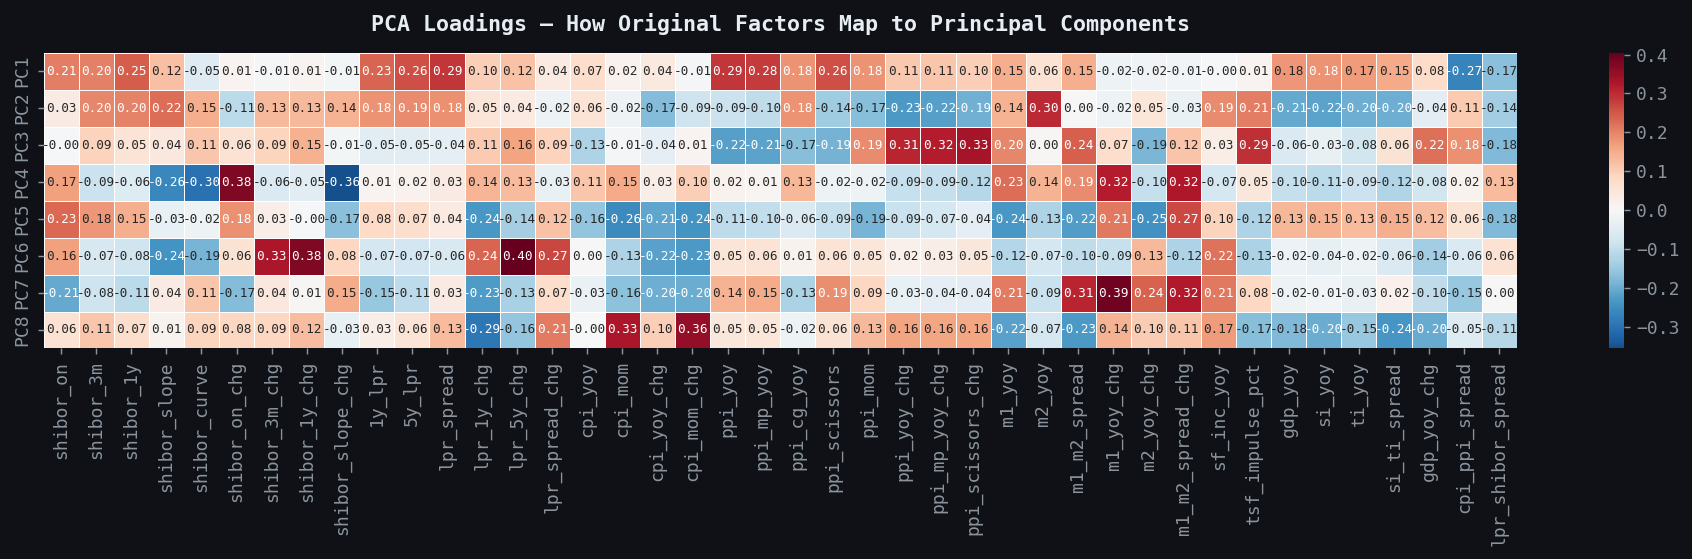

In [27]:
# PCA loading heatmap — which original factors drive each PC
loading_df = pd.DataFrame(
    pca.components_,
    columns=FACTOR_NAMES,
    index=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

fig, ax = plt.subplots(figsize=(0.35 * len(FACTOR_NAMES), 0.55 * N_COMPONENTS))
sns.heatmap(loading_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('PCA Loadings — How Original Factors Map to Principal Components',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [28]:
# regress each stock on PC scores → transform back to original factor space
# we trade a little bit of bias for much more stable coefficient estimates - since we got 60 regressors 
# straight OLS has multicollinearity issues and more volatile coefficient estimates
from src.regression import pca_exposures


pca_exposure_matrix = pd.DataFrame({
    code: pca_exposures(R_aligned[code], PC_scores, pca, FACTOR_NAMES, N_COMPONENTS)[0]
    for code in valid_stocks
}).T
pca_coef_se_matrix = pd.DataFrame({
    code: pca_exposures(R_aligned[code], PC_scores, pca, FACTOR_NAMES, N_COMPONENTS)[1]
    for code in valid_stocks
}).T
gamma_matrix = pd.DataFrame({
    code: pca_exposures(R_aligned[code], PC_scores, pca, FACTOR_NAMES, N_COMPONENTS)[2]
    for code in valid_stocks
}).T

## 7  Comparison — Cosine Similarity Heatmap

Cosine similarity measures how similar two exposure vectors are in *direction*, regardless of magnitude.
A score of 1.0 means identical macro sensitivity profile; 0 means orthogonal; −1 means opposite.

$$\text{sim}(i,j) = \frac{\beta_i \cdot \beta_j}{\|\beta_i\| \|\beta_j\|}$$

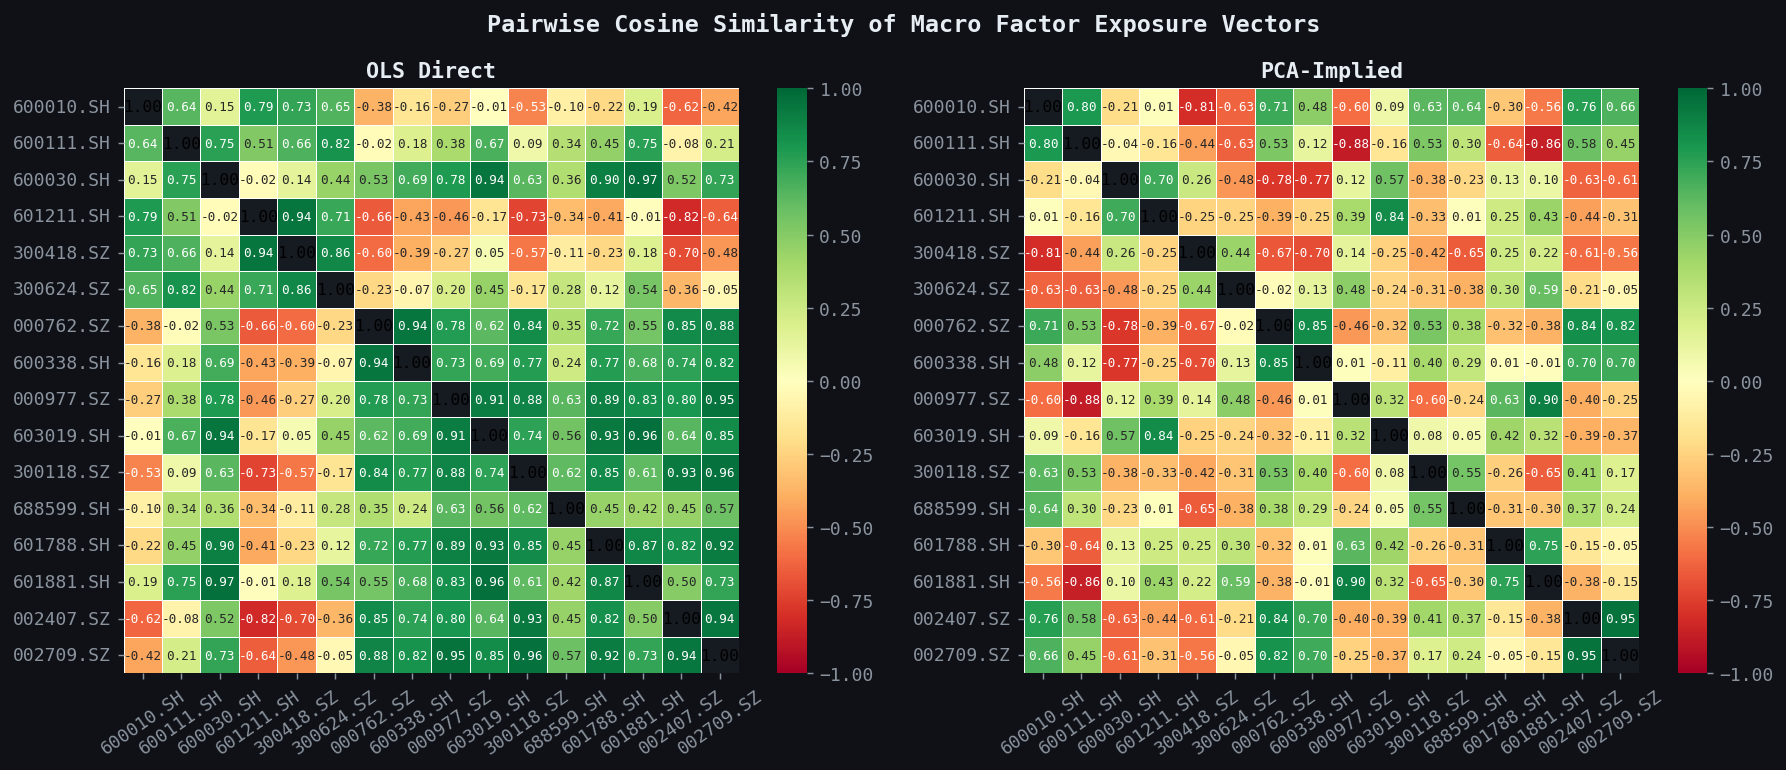

In [29]:
def cosine_sim_matrix(exposure_mat: pd.DataFrame) -> pd.DataFrame:
    """Compute pairwise cosine similarity between all stock exposure vectors."""
    stocks = exposure_mat.index.tolist()
    n = len(stocks)
    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            a = exposure_mat.iloc[i].values
            b = exposure_mat.iloc[j].values
            # cosine distance = 1 − similarity
            if np.linalg.norm(a) > 0 and np.linalg.norm(b) > 0:
                sim[i, j] = 1 - cosine(a, b)
            else:
                sim[i, j] = np.nan
    return pd.DataFrame(sim, index=stocks, columns=stocks)


def plot_cosine_heatmaps(ols_mat, pca_mat):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Pairwise Cosine Similarity of Macro Factor Exposure Vectors',
                 fontweight='bold', fontsize=13)

    for ax, (mat, method) in zip(axes, [(ols_mat, 'OLS Direct'), (pca_mat, 'PCA-Implied')]):
        sim = cosine_sim_matrix(mat)
        mask = np.eye(len(sim), dtype=bool)  # mask diagonal (always 1.0)
        sns.heatmap(
            sim, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax,
            linewidths=0.5, mask=mask,
            annot_kws={'size': 7}
        )
        # add diagonal manually
        for k in range(len(sim)):
            ax.text(k + 0.5, k + 0.5, '1.00',
                    ha='center', va='center', fontsize=9, color='black')
        ax.set_title(method, fontweight='bold')
        ax.tick_params(axis='x', rotation=35)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


plot_cosine_heatmaps(ols_exposure_matrix, gamma_matrix)

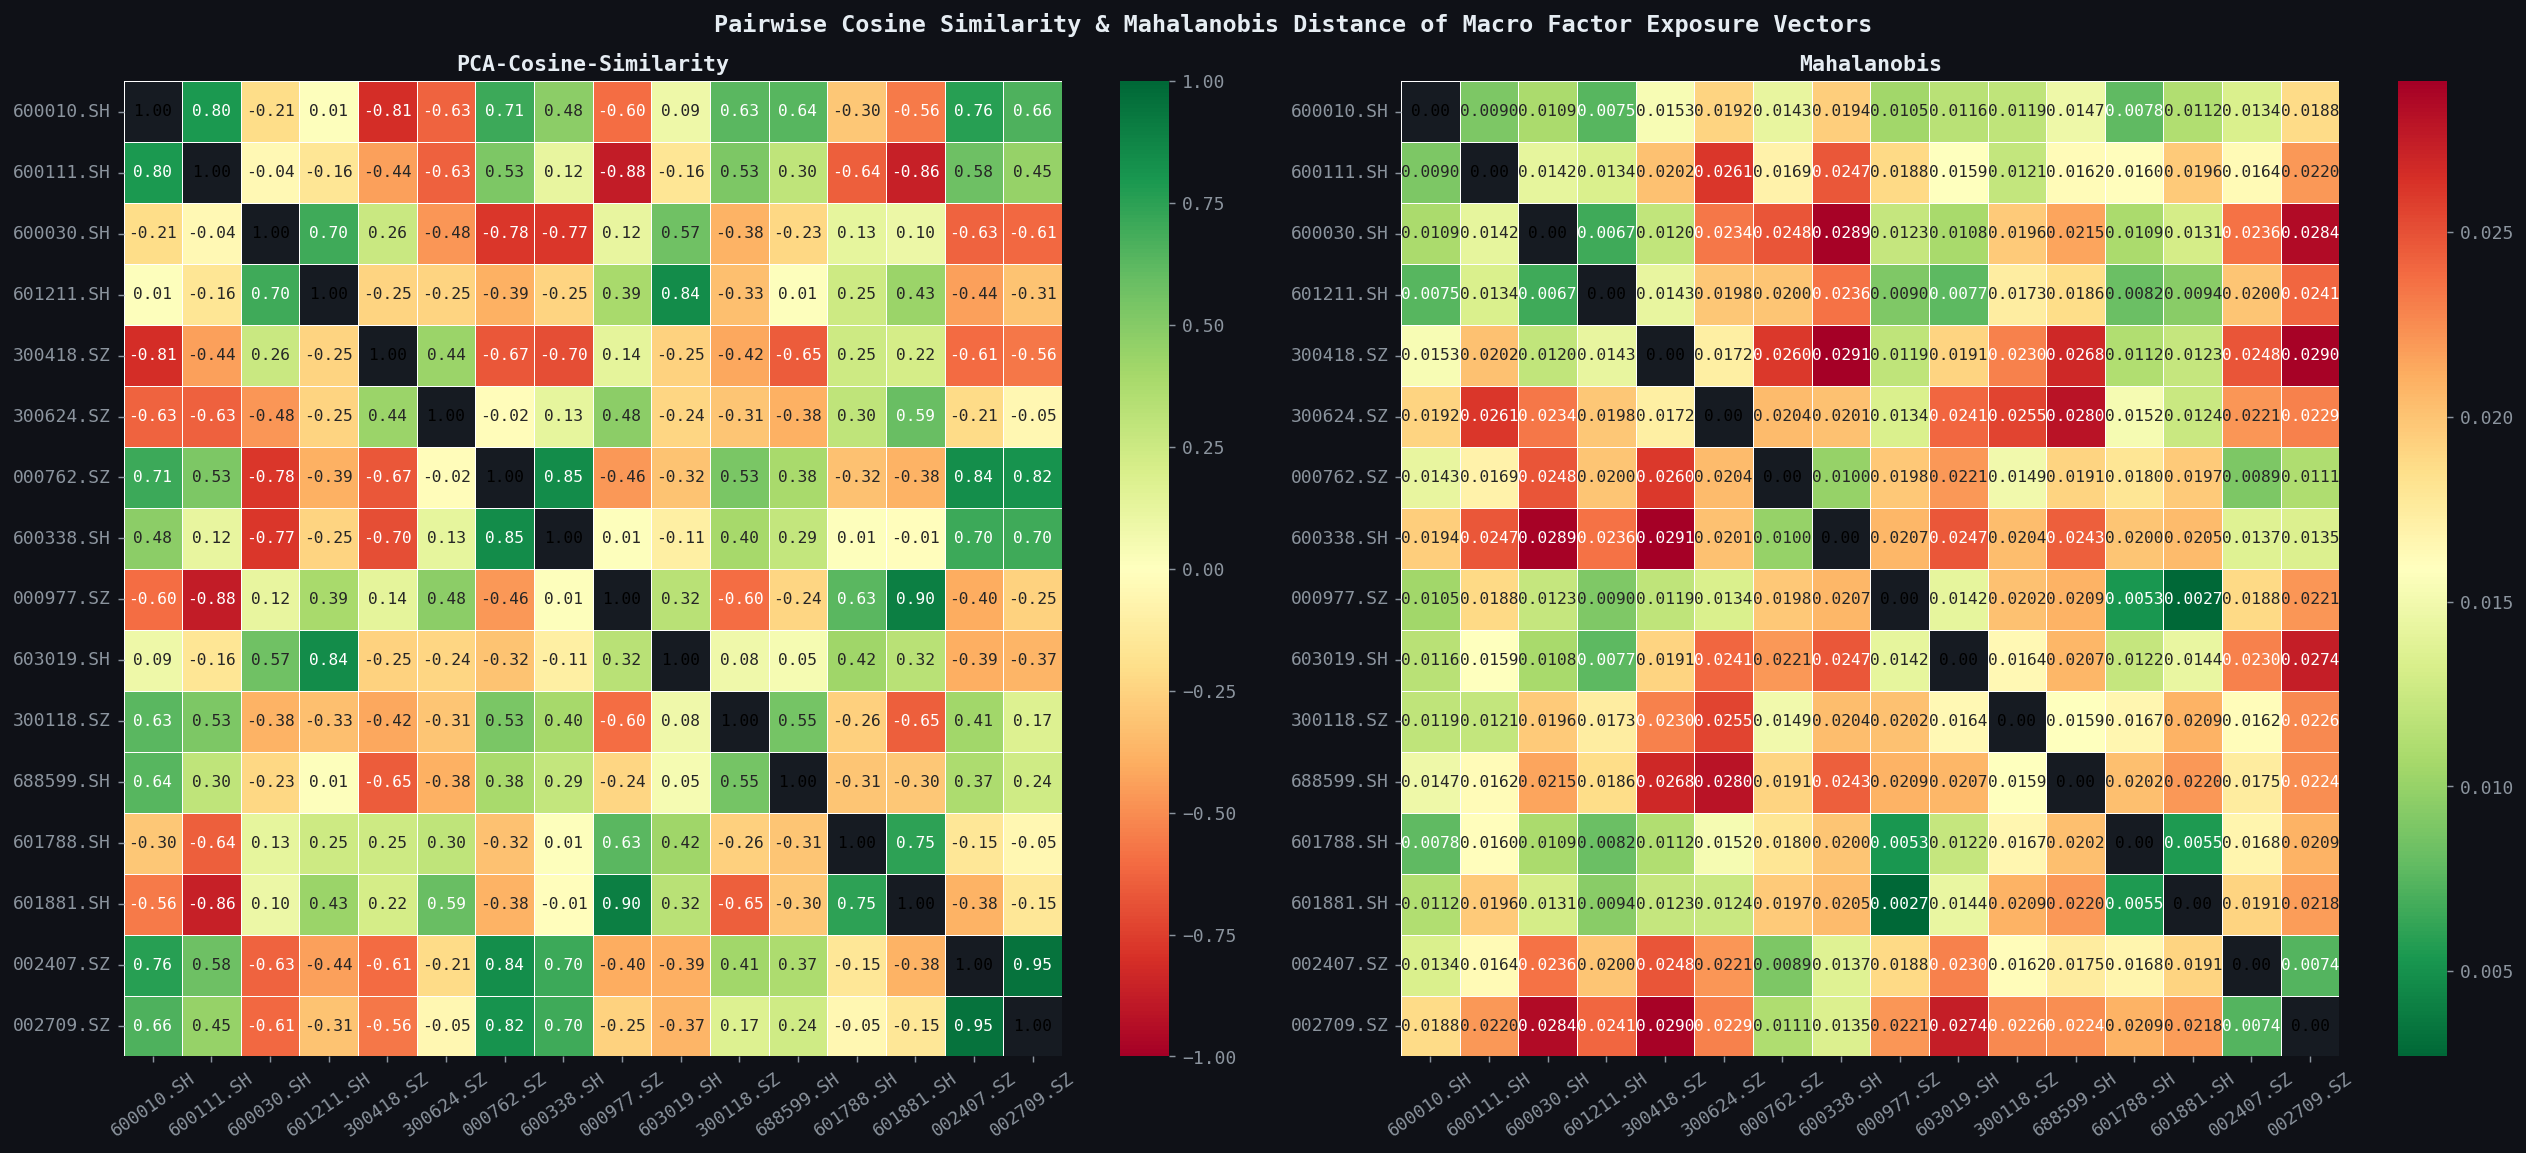

In [30]:
def mahalanobis_matrix(exposure_mat: pd.DataFrame, pca_model: PCA) -> pd.DataFrame:
    stocks = exposure_mat.index.tolist()
    n = len(stocks)
    inv_cov = np.diag(1.0 / pca_model.explained_variance_)  # diagonal, exact
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            diff = exposure_mat.iloc[i].values - exposure_mat.iloc[j].values
            dist[i, j] = np.sqrt(diff @ inv_cov @ diff)
    return pd.DataFrame(dist, index=stocks, columns=stocks)

def plot_pca_mal_heatmaps(pca_mat):

    dist = mahalanobis_matrix(pca_mat, pca)
    sim = cosine_sim_matrix(pca_mat)
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle('Pairwise Cosine Similarity & Mahalanobis Distance of Macro Factor Exposure Vectors',
                 fontweight='bold', fontsize=13)

    for ax, (mat, method, cmap, diag_label, vmin, vmax, floats) in zip(axes, [
        (sim,  'PCA-Cosine-Similarity', 'RdYlGn',   '1.00', -1, 1, '.2f'),
        (dist, 'Mahalanobis',           'RdYlGn_r', '0.00', None, None, '.4f'),
    ]):
        mask = np.eye(len(mat), dtype=bool)
        sns.heatmap(
            mat, annot=True, fmt=floats, cmap=cmap,
            vmin=vmin, vmax=vmax, center=0 if vmin is not None else None, ax=ax,
            linewidths=0.5, mask=mask,
            annot_kws={'size': 9}
        )
        for k in range(len(mat)):
            ax.text(k + 0.5, k + 0.5, diag_label,
                    ha='center', va='center', fontsize=9, color='black')
        ax.set_title(method, fontweight='bold')
        ax.tick_params(axis='x', rotation=35)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


plot_pca_mal_heatmaps(gamma_matrix)

## 8  Deep Dive — Specific Stock Pair

In [31]:
print(STOCK_UNIVERSE)

['600010.SH', '600111.SH', '600030.SH', '601211.SH', '300418.SZ', '300624.SZ', '000762.SZ', '600338.SH', '000977.SZ', '603019.SH', '300118.SZ', '688599.SH', '601788.SH', '601881.SH', '002407.SZ', '002709.SZ']


In [32]:
STOCK_A = "002407.SZ"   # primary comparison stock
STOCK_B = "002709.SZ"   # secondary comparison stock


# These pairs have adf-t < -4 AND Minimum 0.7 cosine similarity 
# pair_1: (600010.SH, 600111.SH) - 0.8, 
# pair_2: (600030.SH, 601211.SH) - 0.7
# pair_3: (000762.SZ, 600338.SH) - 0.85
# pair_4: (601788.SH, 601881.SH) - 0.75
# pair_5: (002407.SZ, 002709.SZ) - 0.95
# this means that these stocks hedge each other against change in macro factors reasonably well

In [ ]:
from src.pair_trading_engine import PairTradingConfig, MultiPairTradingConfig

# Example multi-pair trading configuration using the selected candidate pairs.
# Adjust start_date/end_date to match your available price history.
pair_cfgs = [
    PairTradingConfig(
        ts_code_a="600010.SH",
        ts_code_b="600111.SH",
        pair_name="pair_1",
        start_date="20220101",
        end_date="20231231",
    ),
    PairTradingConfig(
        ts_code_a="600030.SH",
        ts_code_b="601211.SH",
        pair_name="pair_2",
        start_date="20220101",
        end_date="20231231",
    ),
    PairTradingConfig(
        ts_code_a="000762.SZ",
        ts_code_b="600338.SH",
        pair_name="pair_3",
        start_date="20220101",
        end_date="20231231",
    ),
    PairTradingConfig(
        ts_code_a="601788.SH",
        ts_code_b="601881.SH",
        pair_name="pair_4",
        start_date="20220101",
        end_date="20231231",
    ),
    PairTradingConfig(
        ts_code_a="002407.SZ",
        ts_code_b="002709.SZ",
        pair_name="pair_5",
        start_date="20220101",
        end_date="20231231",
    ),
]

multi_pair_cfg = MultiPairTradingConfig(
    pairs=pair_cfgs,
    start_date="20220101",
    end_date="20231231",
    capital=1_000_000.0,
    cash_buffer_pct=0.05,
    db_path=PRICES_DB,
)

pair_cfgs, multi_pair_cfg

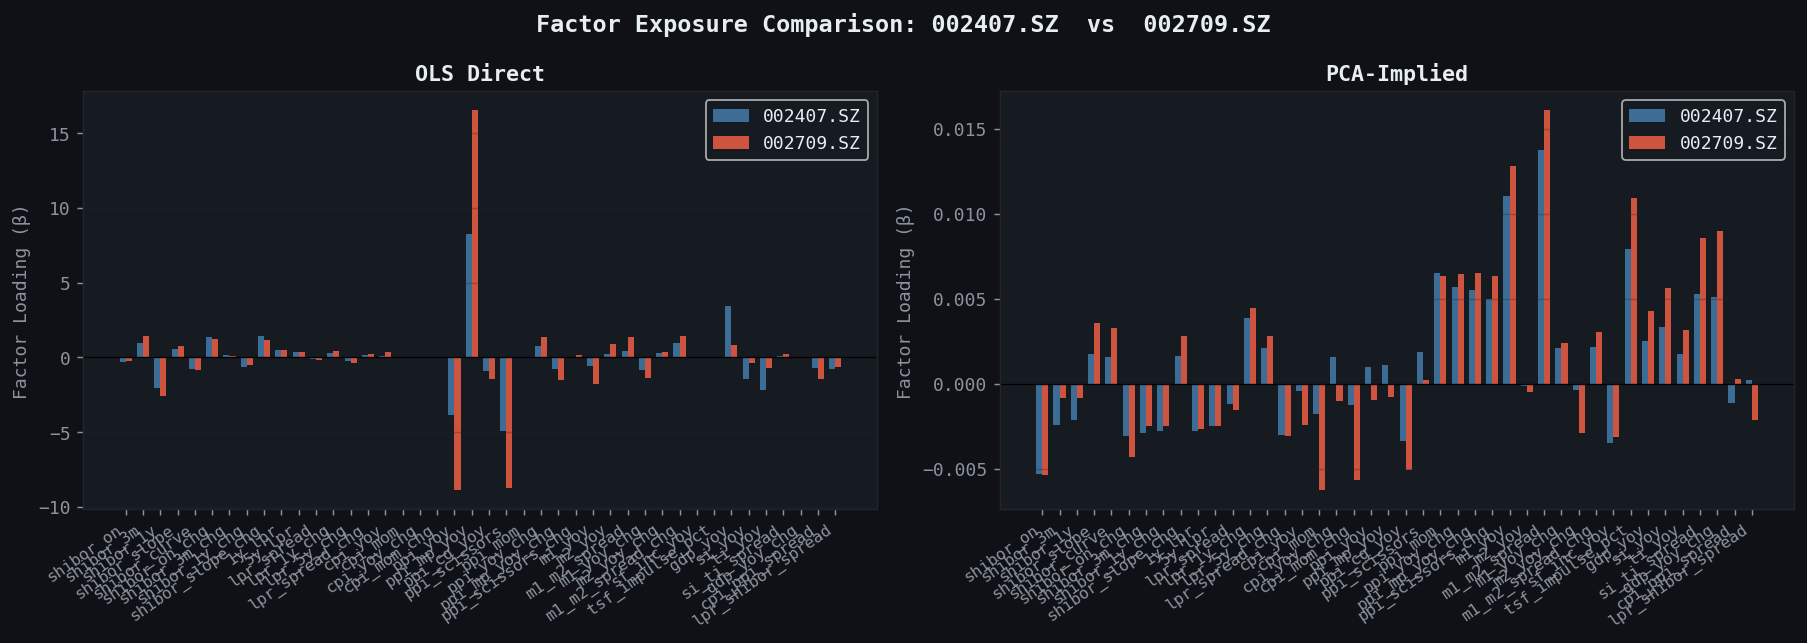


OLS beta difference (A − B):
shibor_on           -0.0362
shibor_3m           -0.5164
shibor_1y            0.5135
shibor_slope        -0.1660
shibor_curve         0.1113
shibor_on_chg        0.1316
shibor_3m_chg        0.1047
shibor_1y_chg       -0.1450
shibor_slope_chg     0.2077
1y_lpr               0.0166
5y_lpr               0.0245
lpr_spread           0.0407
lpr_1y_chg          -0.0986
lpr_5y_chg           0.1087
lpr_spread_chg      -0.0658
cpi_yoy             -0.2663
cpi_mom              0.0298
cpi_yoy_chg          0.0056
cpi_mom_chg          0.0120
ppi_yoy              5.0280
ppi_mp_yoy          -8.2589
ppi_cg_yoy           0.5596
ppi_scissors         3.7928
ppi_mom             -0.0182
ppi_yoy_chg         -0.6139
ppi_mp_yoy_chg       0.7270
ppi_scissors_chg    -0.1248
m1_yoy               1.2150
m2_yoy              -0.6240
m1_m2_spread        -0.9476
m1_yoy_chg           0.4827
m2_yoy_chg          -0.1121
m1_m2_spread_chg    -0.5171
sf_inc_yoy          -0.0080
tsf_impulse_pct   

In [33]:
def plot_exposure_comparison(ols_mat: pd.DataFrame, pca_mat: pd.DataFrame,
                              stock_a: str, stock_b: str):
    """
    Side-by-side bar charts comparing two stocks' factor exposures
    under both OLS and PCA methods.
    """
    stocks = [s for s in [stock_a, stock_b] if s in ols_mat.index]
    if len(stocks) < 2:
        print(f'One or both stocks not in valid universe: {stocks}')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f'Factor Exposure Comparison: {stock_a}  vs  {stock_b}',
                 fontweight='bold', fontsize=13)

    colors = ['steelblue', 'tomato']
    x = np.arange(len(FACTOR_NAMES))
    width = 0.35

    for ax, (mat, method) in zip(axes, [(ols_mat, 'OLS Direct'), (pca_mat, 'PCA-Implied')]):
        for i, (s, c) in enumerate(zip(stocks, colors)):
            vals = mat.loc[s, FACTOR_NAMES].values
            ax.bar(x + (i - 0.5) * width, vals, width, label=s, color=c, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(FACTOR_NAMES, rotation=35, ha='right', fontsize=9)
        ax.set_title(method, fontweight='bold')
        ax.set_ylabel('Factor Loading (β)')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # print numeric diff
    diff = (ols_mat.loc[stock_a, FACTOR_NAMES] - ols_mat.loc[stock_b, FACTOR_NAMES]).rename('OLS β diff (A−B)')
    print('\nOLS beta difference (A − B):')
    print(diff.round(4).to_string())

plot_exposure_comparison(ols_exposure_matrix, pca_exposure_matrix, STOCK_A, STOCK_B)

In [34]:
# ── rolling betas for STOCK_A and STOCK_B ─────────────────────────────────────
roll_A, roll_B = None, None

if STOCK_A in valid_stocks:
    roll_A = ols_rolling_exposures(R_aligned[STOCK_A], F_aligned, ROLLING_WINDOW, N_COMPONENTS)
    print(f'Rolling betas computed for {STOCK_A}: {roll_A.shape}')

if STOCK_B in valid_stocks:
    roll_B = ols_rolling_exposures(R_aligned[STOCK_B], F_aligned, ROLLING_WINDOW, N_COMPONENTS)
    print(f'Rolling betas computed for {STOCK_B}: {roll_B.shape}')

Rolling betas computed for 002407.SZ: (37, 42)
Rolling betas computed for 002709.SZ: (37, 42)


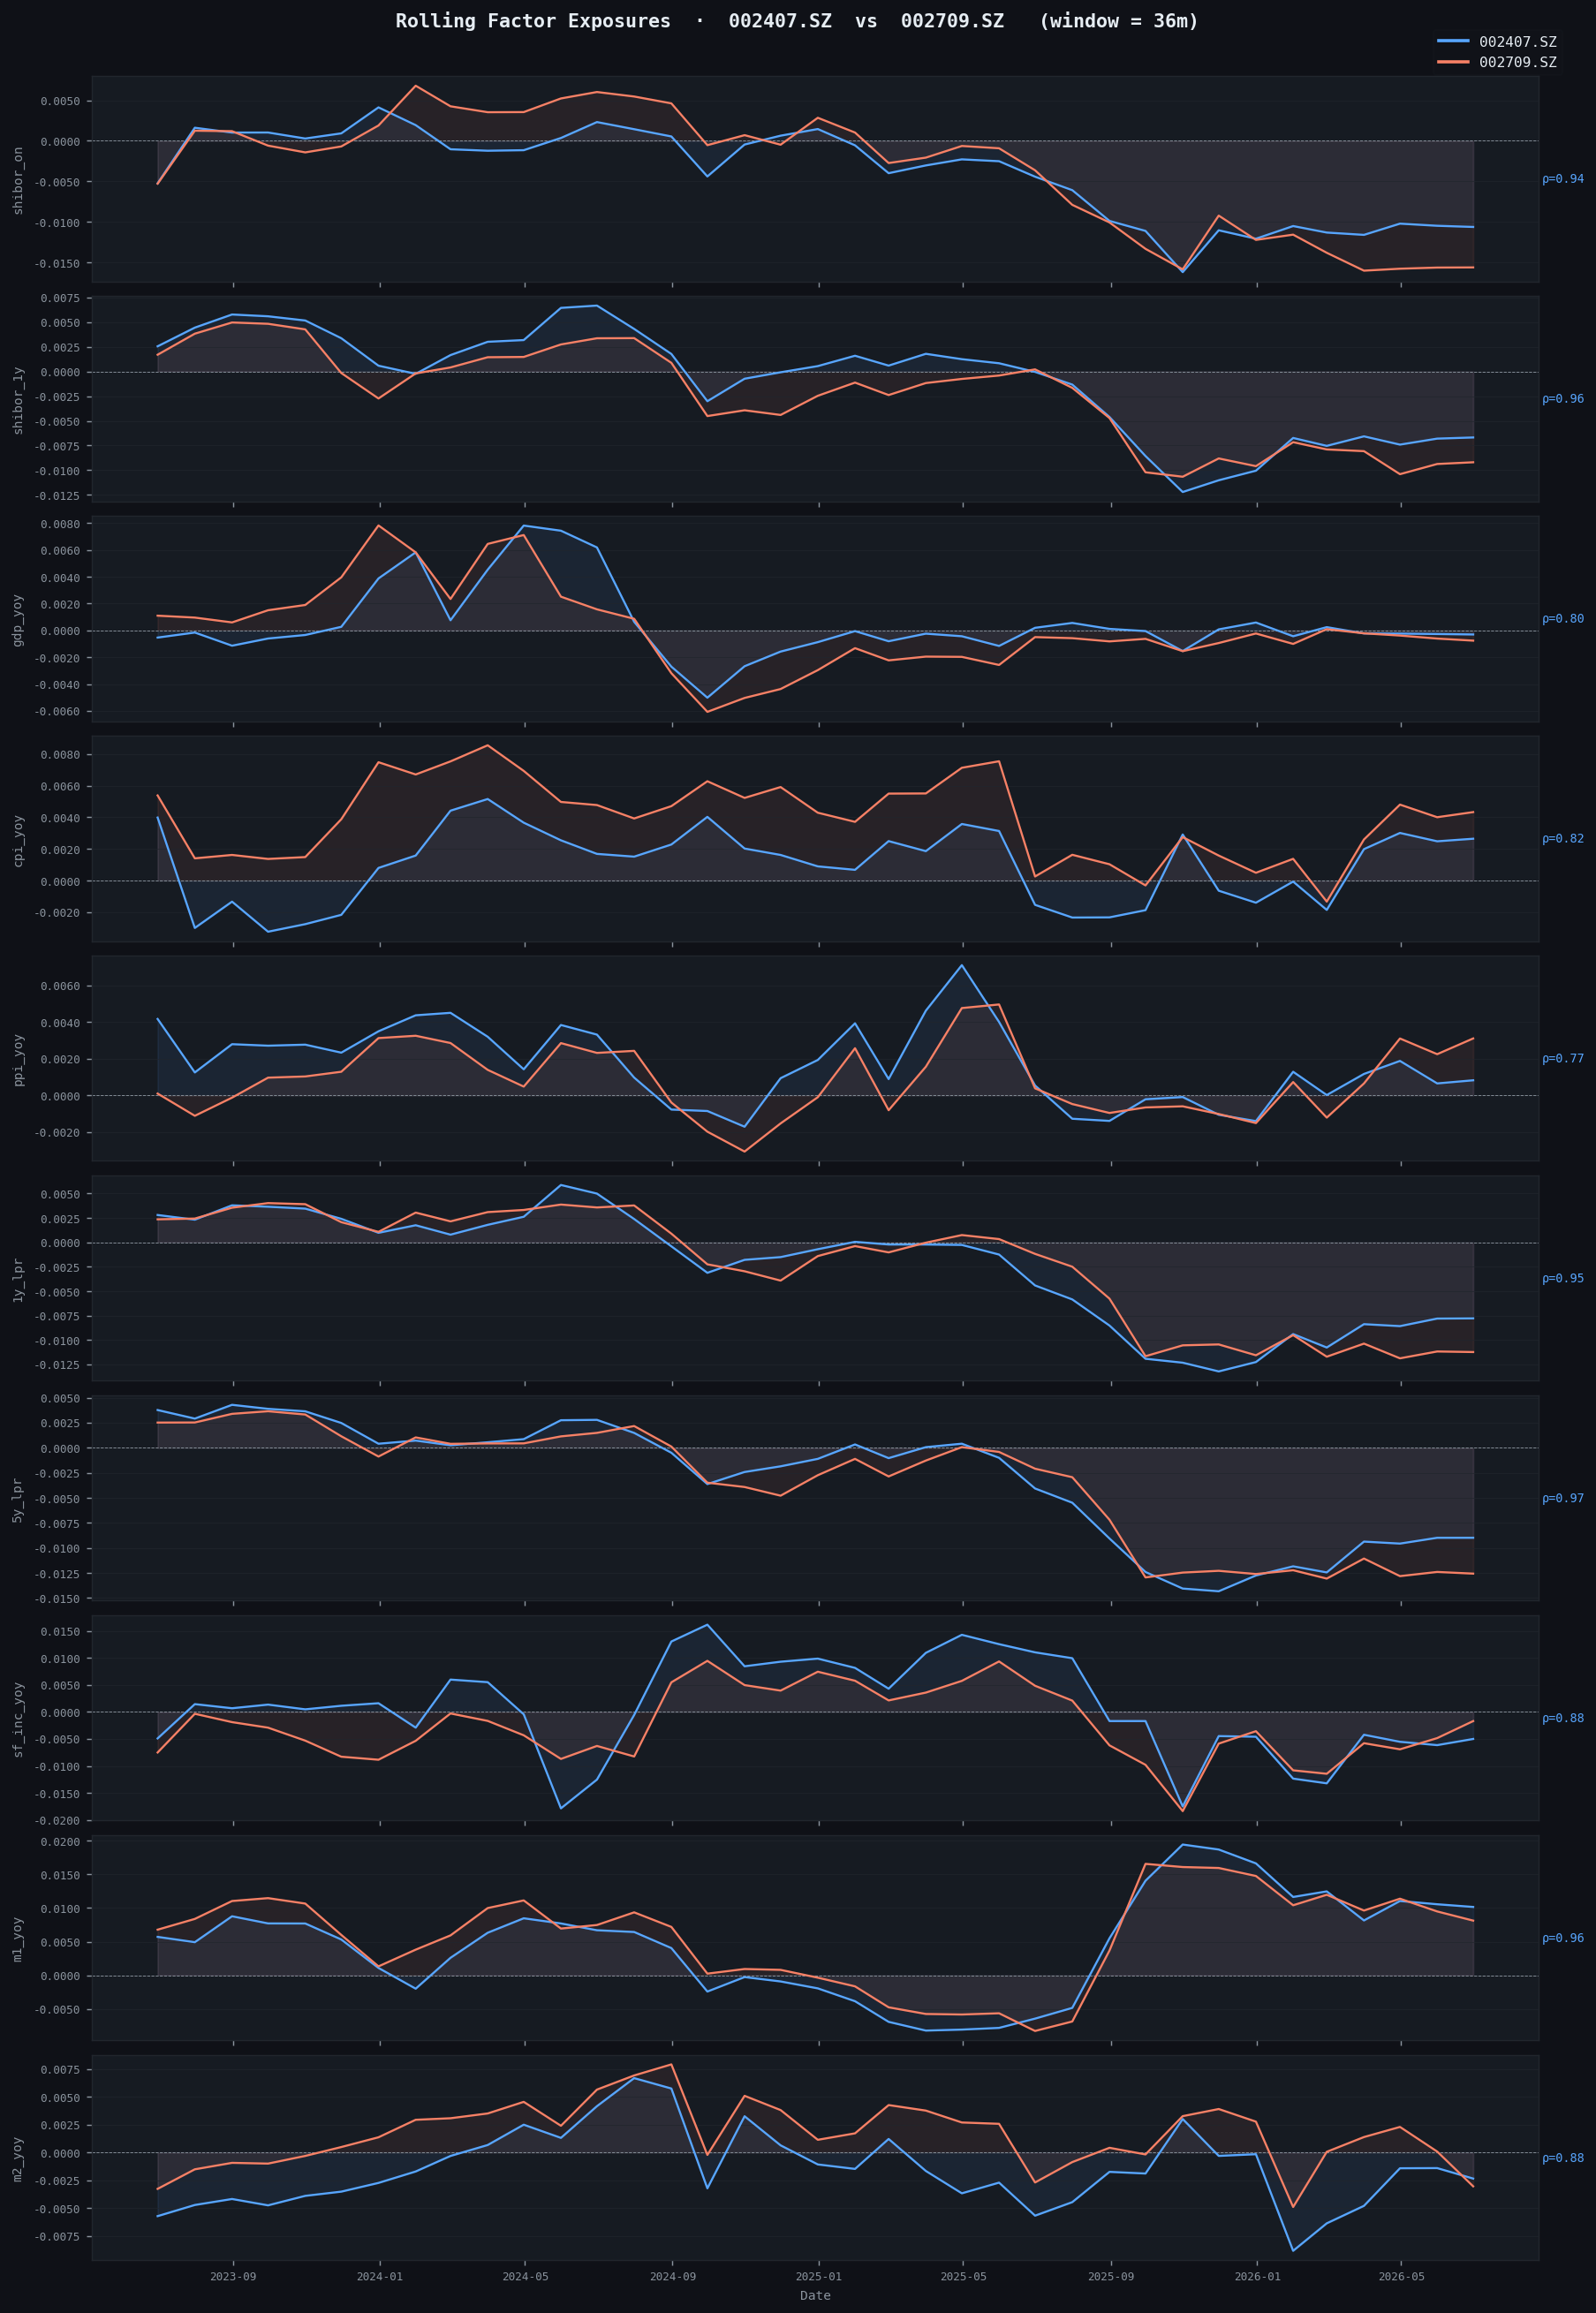

In [35]:
# # ── plot rolling betas for stock A ───────────────────────────────────────────

factors_to_plot = [
    'shibor_on','shibor_1y','gdp_yoy','cpi_yoy','ppi_yoy',
    '1y_lpr','5y_lpr','sf_inc_yoy','m1_yoy','m2_yoy'
]

# ── build figure ──────────────────────────────────────────────────────────────
n = len(factors_to_plot)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.0 * n), sharex=True)
fig.patch.set_facecolor(BG)

fig.suptitle(
    f'Rolling Factor Exposures  ·  {STOCK_A}  vs  {STOCK_B}   (window = {ROLLING_WINDOW}m)',
    fontsize=12, fontweight='bold', color=TEXT, y=1.005
)

for ax, col in zip(axes, factors_to_plot):
    has_A = roll_A is not None and col in roll_A.columns
    has_B = roll_B is not None and col in roll_B.columns

    if has_A:
        ax.plot(roll_A.index, roll_A[col],
                color=COL_A, linewidth=1.3, label=STOCK_A, zorder=3)
        ax.fill_between(roll_A.index, roll_A[col], 0,
                        alpha=0.08, color=COL_A)

    if has_B:
        ax.plot(roll_B.index, roll_B[col],
                color=COL_B, linewidth=1.3, label=STOCK_B, zorder=3)
        ax.fill_between(roll_B.index, roll_B[col], 0,
                        alpha=0.08, color=COL_B)

    ax.axhline(0, color=SUBTEXT, linewidth=0.5, linestyle='--', zorder=2)
    ax.grid(True, axis='y', linewidth=0.4)
    ax.set_ylabel(col, fontsize=8, labelpad=6)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.tick_params(axis='both', labelsize=7)

    # rolling correlation as subtitle on each panel
    if has_A and has_B:
        corr = roll_A[col].corr(roll_B[col])
        sign_color = COL_A if corr > 0 else COL_B
        ax.text(1.002, 0.5, f'ρ={corr:.2f}',
                transform=ax.transAxes, fontsize=7.5,
                color=sign_color, va='center', ha='left')

# ── shared legend at top ──────────────────────────────────────────────────────
handles = [
    plt.Line2D([0],[0], color=COL_A, linewidth=2, label=STOCK_A),
    plt.Line2D([0],[0], color=COL_B, linewidth=2, label=STOCK_B),
]
fig.legend(handles=handles, loc='upper right', fontsize=9,
           framealpha=0.15, facecolor=PANEL, edgecolor=GRID,
           bbox_to_anchor=(0.98, 1.0))

axes[-1].set_xlabel('Date', fontsize=8)
plt.tight_layout(h_pad=0.4)
plt.show()

In [36]:
# Since raw OLS turned out to be useless we are going to drop that and focus on PCA

def compare_pair(stock_a: str, stock_b: str,
                 mat: pd.DataFrame):
    """
    Print a detailed similarity report for two specific stocks.
    """
    if stock_a not in mat.index or stock_b not in mat.index:
        print('One or both stocks missing from exposure matrix.')
        return

    print(f'{'─'*55}')
    print(f'  Macro Exposure Similarity Report')
    print(f'  Stock A : {stock_a}')
    print(f'  Stock B : {stock_b}')
    print(f'{'─'*55}')

    a = mat.loc[stock_a].values
    b = mat.loc[stock_b].values
    sim = 1 - cosine(a, b)
    l2  = np.linalg.norm(a - b)
    cov = np.cov(mat.values.T)
    inv_cov = np.linalg.pinv(cov)  # pinv for numerical stability
    diff = a - b
    mahalanobis = np.sqrt(diff @ inv_cov @ diff)

    print(f'\n  [PCA-based OLS]')
    print(f'    Cosine similarity : {sim:+.4f}')
    print(f'    L2 distance       : {l2:.4f}')
    print(f'    Mahalanobis distance       : {mahalanobis:.4f}')
    print(f'\n  Factor loadings comparison (PCA-based OLS):')
    tbl = pd.DataFrame({
        stock_a: mat.loc[stock_a],
        stock_b: mat.loc[stock_b],
        'diff (A−B)': mat.loc[stock_a] - mat.loc[stock_b],
        'dominant': (mat.loc[stock_a].abs() > mat.loc[stock_b].abs()).map(
            {True: stock_a, False: stock_b})
    })
    print(tbl.round(4).to_string())

    # interpretation
    print(f'\n  Interpretation:')
    if sim > 0.9:
        print('  → Very high similarity. Stocks share nearly identical macro sensitivity.')
        print('    Pair trading based on macro divergence is risky — they move together.')
    elif sim > 0.6:
        print('  → Moderate similarity. Shared macro drivers exist but stock-specific')
        print('    factors also play a role. Check idiosyncratic residuals.')
    elif sim > 0.2:
        print('  → Low similarity. Macro profiles differ meaningfully.')
        print('    Useful for portfolio diversification across macro regimes.')
    else:
        print('  → Near-zero or negative similarity. Opposite macro sensitivity.')
        print('    Strong candidate for macro-neutral long/short pair.')
    print(f'{'─'*55}')

compare_pair(STOCK_A, STOCK_B, pca_exposure_matrix)

───────────────────────────────────────────────────────
  Macro Exposure Similarity Report
  Stock A : 002407.SZ
  Stock B : 002709.SZ
───────────────────────────────────────────────────────

  [PCA-based OLS]
    Cosine similarity : +0.9507
    L2 distance       : 0.0122
    Mahalanobis distance       : 2.5501

  Factor loadings comparison (PCA-based OLS):
                   002407.SZ  002709.SZ  diff (A−B)   dominant
shibor_on            -0.0053    -0.0054      0.0001  002709.SZ
shibor_3m            -0.0024    -0.0009     -0.0016  002407.SZ
shibor_1y            -0.0021    -0.0008     -0.0013  002407.SZ
shibor_slope          0.0018     0.0036     -0.0018  002709.SZ
shibor_curve          0.0016     0.0033     -0.0017  002709.SZ
shibor_on_chg        -0.0031    -0.0043      0.0012  002709.SZ
shibor_3m_chg        -0.0029    -0.0025     -0.0004  002407.SZ
shibor_1y_chg        -0.0027    -0.0025     -0.0003  002407.SZ
shibor_slope_chg      0.0017     0.0028     -0.0011  002709.SZ
1y_lpr    

In [37]:
# To check two stocks:
# 1. run the cosine similarity heatmap $ check mahalanobis
# 2. run the rolling OLS and see how they correlate
# 3. check fundamentals - read their 10k or 10k equivalent